# Task 3 - Iris Flower Classification

### Objective

To build a machine learning model that classifies Iris flowers into different species based on their sepal and petal measurements.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Iris dataset

from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target

print("Iris dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Iris dataset loaded successfully!
Shape of dataset: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 1. Understanding the Dataset

The Iris dataset contains measurements of Iris flowers.
The flowers belong to three different species.

The main measurements are:
- Sepal length
- Sepal width
- Petal length
- Petal width


In [3]:
# Display basic information about the dataset

print("Dataset Information:")
df.info()

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Dataset Shape:
(150, 5)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


## 2. Preparing the Target Labels

The Iris dataset contains three flower species:
Setosa, Versicolor and Virginica.

We will convert the numerical target values into their actual species names.



In [4]:
# Convert numerical target values into species names

species_names = {
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
}

df['species'] = df['species'].map(species_names)

print("Species labels:")
print(df['species'].value_counts())

df.head()

Species labels:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Data Visualization

Visualization helps us understand the differences between the three Iris flower species.

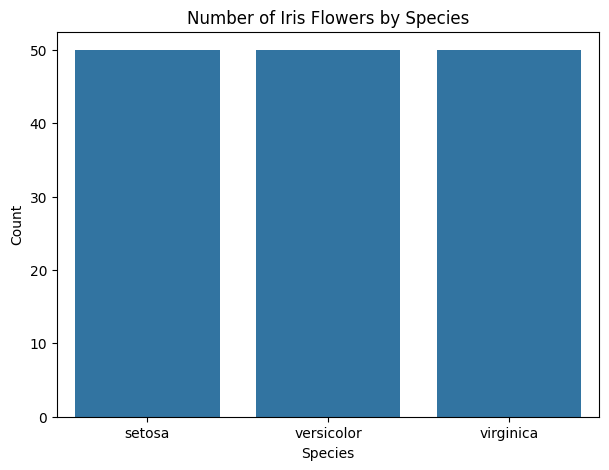

In [5]:
# Visualize the number of flowers in each species

plt.figure(figsize=(7,5))

sns.countplot(x='species', data=df)

plt.title('Number of Iris Flowers by Species')
plt.xlabel('Species')
plt.ylabel('Count')

plt.show()

## 4. Comparing Flower Measurements

We will compare the sepal and petal measurements of the three Iris species.

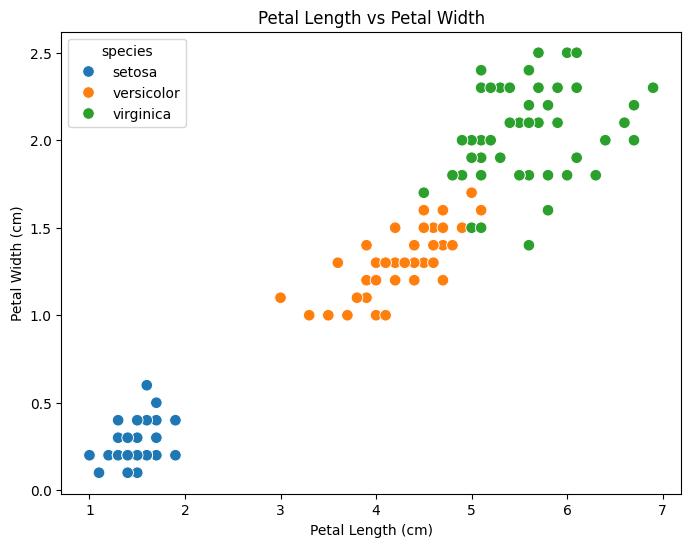

In [6]:
# Compare petal length and petal width

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    data=df,
    s=70
)

plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

plt.show()

## 5. Preparing Data for Machine Learning

The flower measurements will be used as input features, while the flower species will be the target variable.


In [7]:
# Define features and target

X = df.drop('species', axis=1)
y = df['species']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


In [8]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


## 6. Machine Learning Model

A Random Forest Classifier is used to classify Iris flowers into their respective species.

In [9]:
# Create and train the Random Forest Classifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


## 7. Model Evaluation

The performance of the Random Forest Classifier is evaluated using accuracy and a classification report.

In [11]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 90.0 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## 8. Confusion Matrix

The confusion matrix shows how accurately the model classified each Iris flower species.

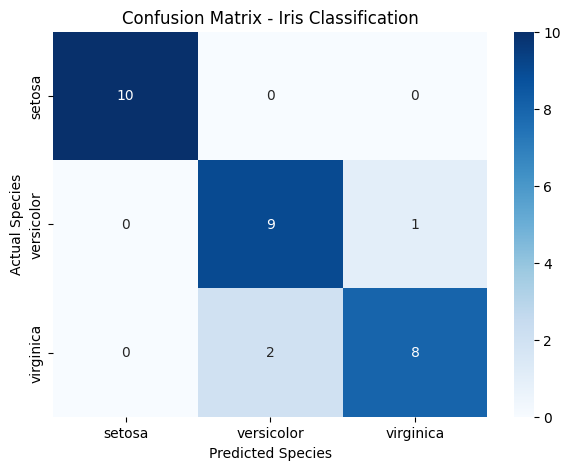

In [12]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['setosa', 'versicolor', 'virginica'],
    yticklabels=['setosa', 'versicolor', 'virginica']
)

plt.title('Confusion Matrix - Iris Classification')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')

plt.show()

## 9. Conclusion

The Iris Flower Classification project was successfully completed using Python and machine learning.

The Iris dataset was analyzed and visualized using different graphs.

A Random Forest Classifier was trained using sepal and petal measurements to classify flowers into Setosa, Versicolor and Virginica.

The model was evaluated using accuracy, classification report and confusion matrix.

This project demonstrates the basic Data Science workflow including data loading, data preprocessing, data visualization, model training and model evaluation.
